# I give up changing the axes. It is not rewarding enough for my career.
All definition in the code duration calculation is intuiative (x,y,z) = (0,1,2)
The title in the figure use the same axes as that of XPP hutch.
At all other cases, please read the code carefully to determine the relation between, x,y,z and 0,1,2

## Definition
1. um, fs, keV
2. normal is pointing inwards the reflection surface
3. The coordinate convention of this simulation and its relation to XPP coordinate is 
    (axis 0, axis 1, axis 2) = (code x, code y, code z) = (vertical, horizontal, propagation) = (xpp y, xpp x, xpp z)
    i.e., The name in this code is x,y,z, using one convension. In the text, use the XPP convention 
   
## Convention for FFT

np.fft(field) = spectrum

np.ifft(spectrum) = field

# Step 1: Ray Tracing Calculation

In [1]:
import numpy as np
import sys
import matplotlib.pyplot as plt
from matplotlib import colormaps

sys.path.append("../../../../XRaySimulation")

from XRaySimulation import Pulse, DeviceSimu, util, Crystal
from rayTracingCalculation import prepare_beam_optics, get_miniSD_and_TG_trajectory, \
    get_coefficient_for_two_configurations, get_trajectory_dependence_on_various_parameters

import physicalModelVisualization
import eFieldProcessing

plt.rcParams.update({'font.size': 14})

In [2]:
expSimu = get_miniSD_and_TG_trajectory()
(t2x_coef, t3x_coef, t4x_coef, t5x_coef,
 probe1z_coef, probe1alpha_coef, probe2z_coef,
 pump1z_coef, pump1alpha_coef, pump2z_coef, pump2alpha_coef) = get_trajectory_dependence_on_various_parameters()

/global/cfs/cdirs/lcls/xpcs/md/haoyuan/autoAlignment/XRaySimulation/Projects/autoAlign/notebooks/../../../../XRaySimulation/XRaySimulation/Crystal.py:233: RuntimeWarning: invalid value encountered in divide
  direction1 /= np.linalg.norm(direction1)


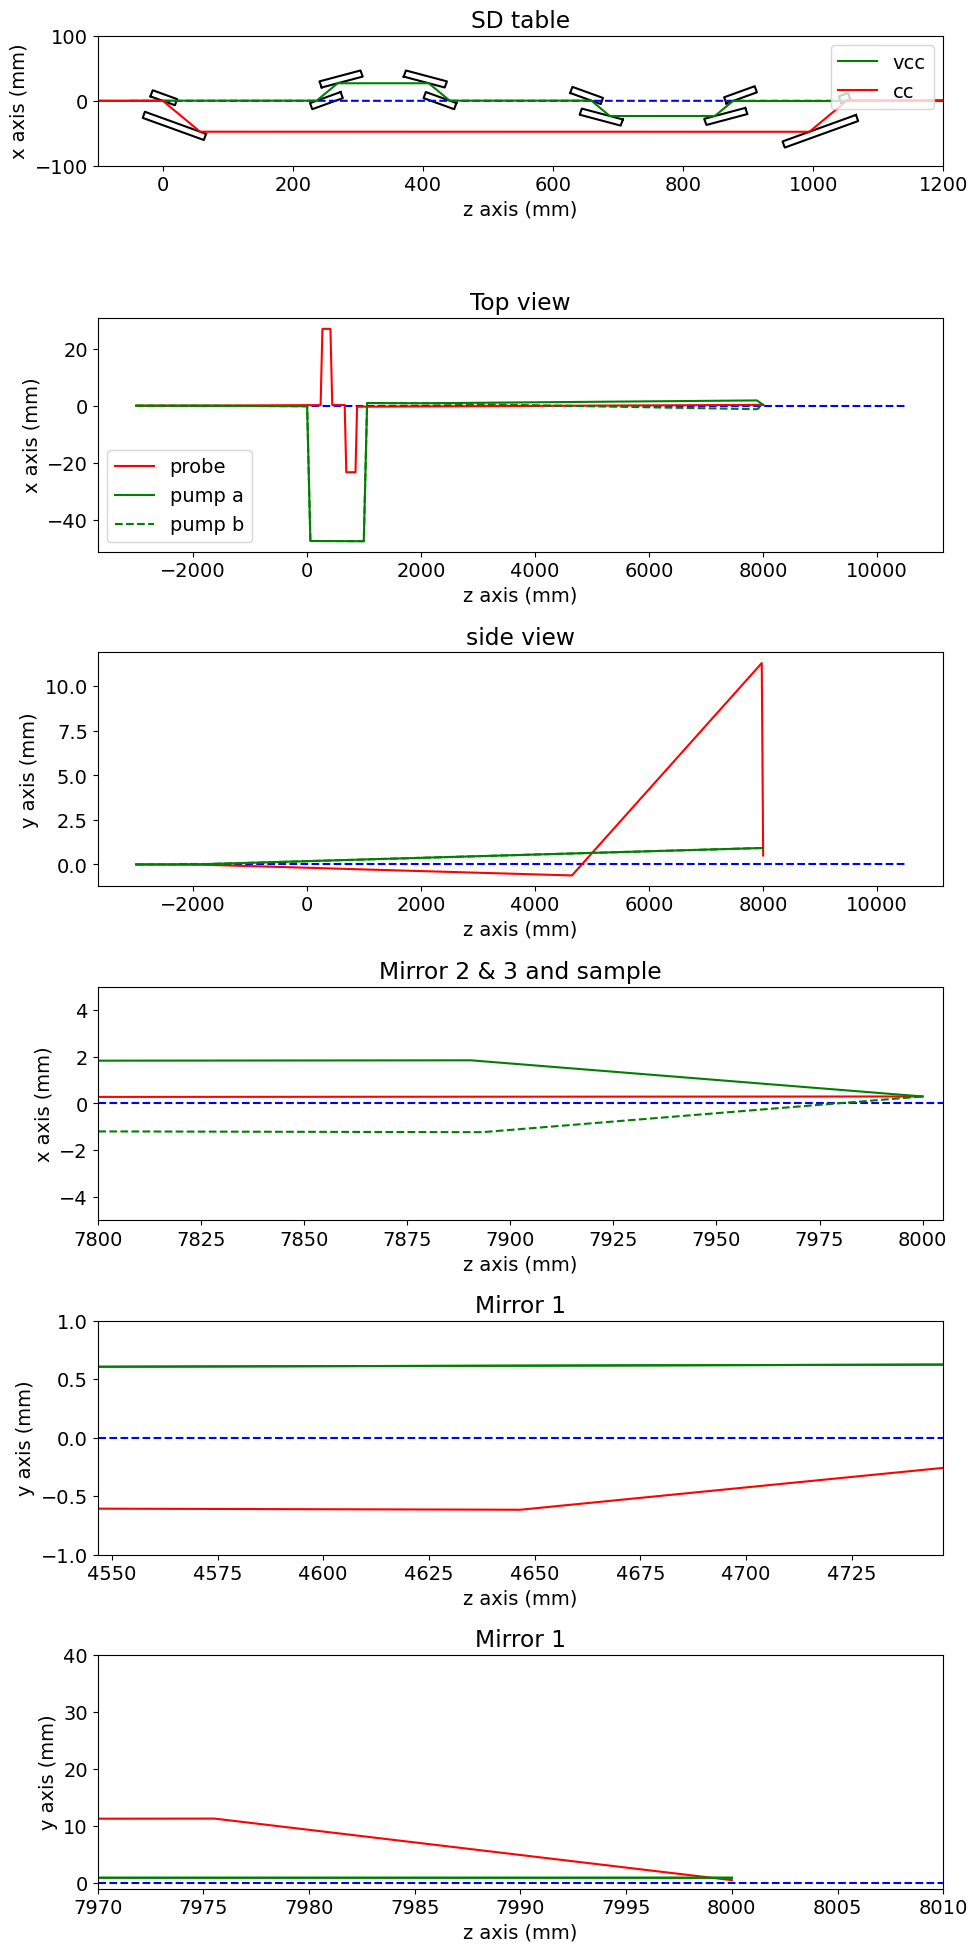

In [3]:
physicalModelVisualization.showSDandTGtrajectory(simulation_summary=expSimu)

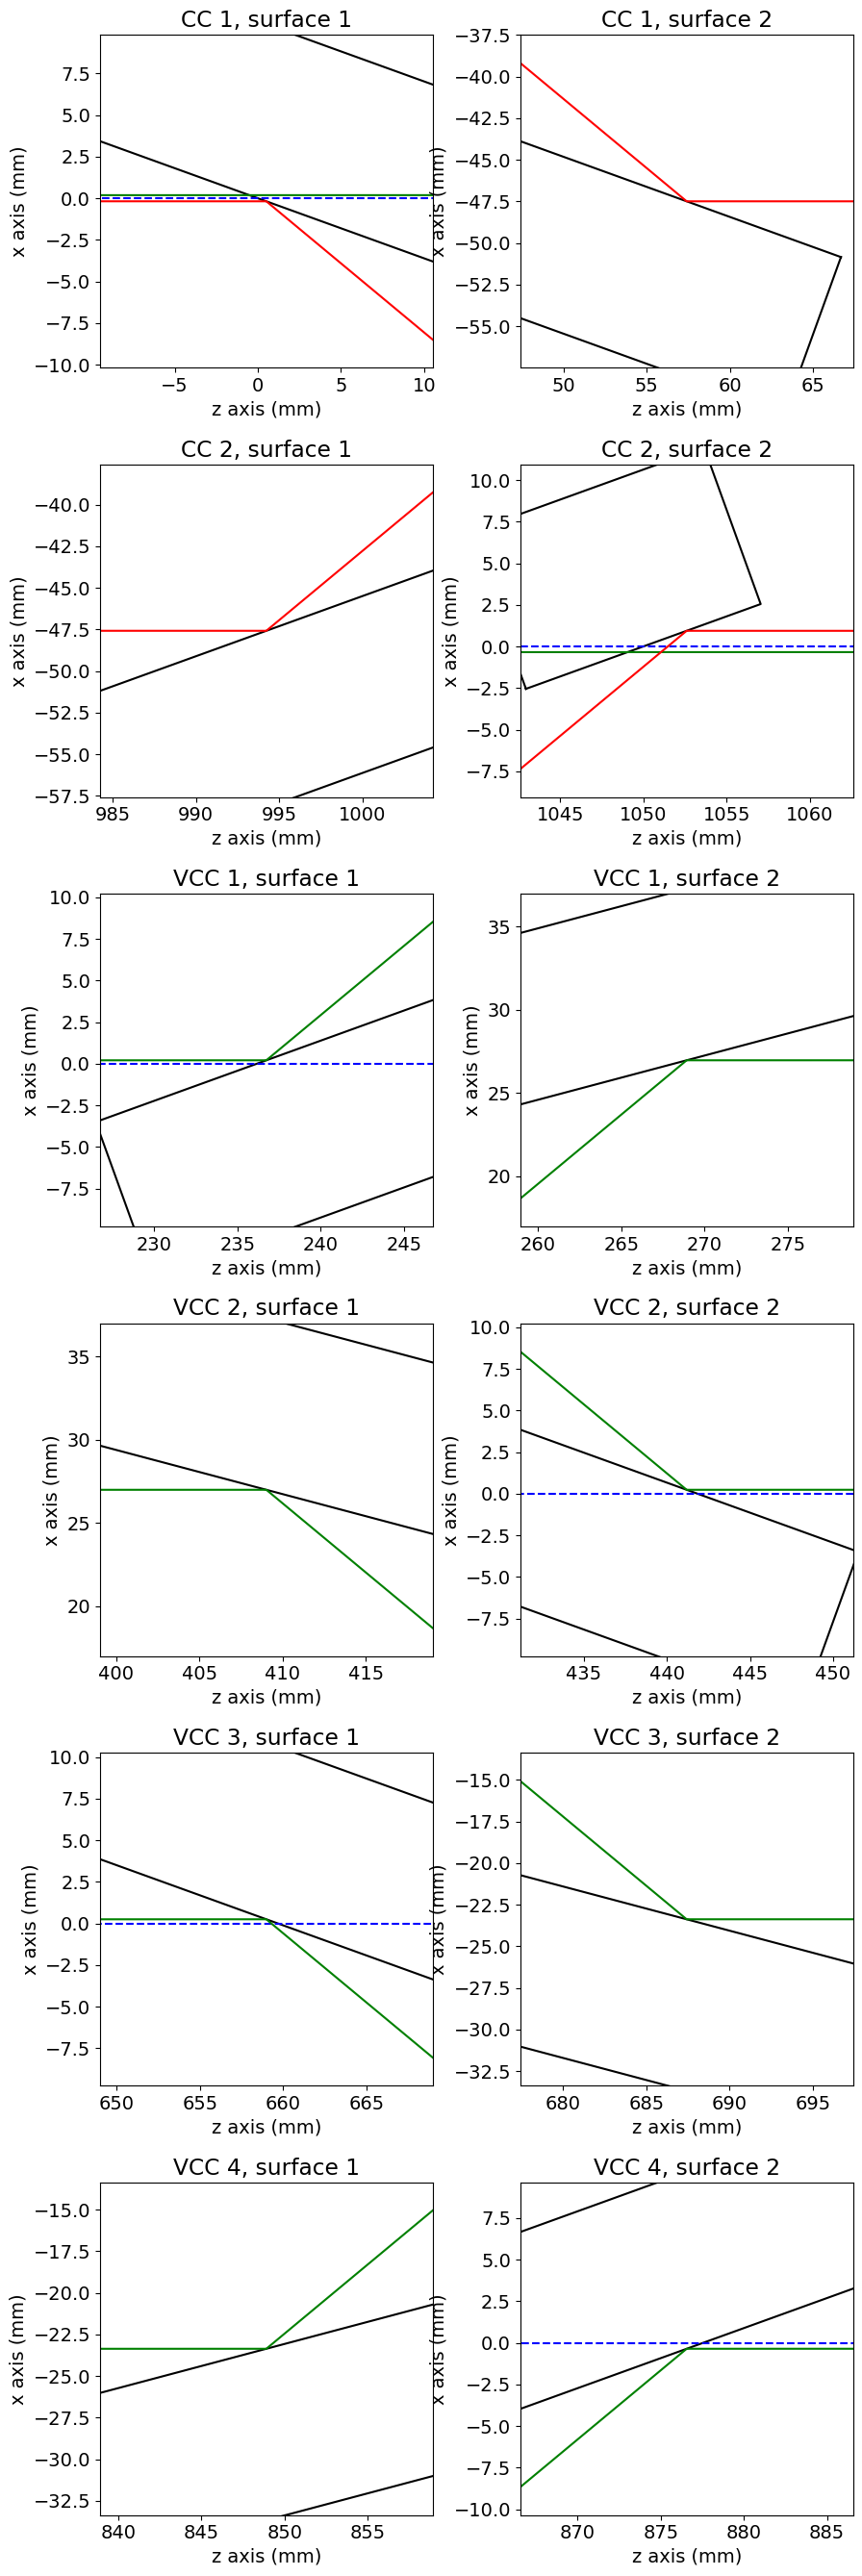

In [4]:
physicalModelVisualization.showCrystalEdges(simulation_summary=expSimu)

In [5]:
# Calculate the modification needed to impose to these optics
# -------------------------------------------------------
#     Overlap the TG pulse pair along the x axis
# -------------------------------------------------------
# Get current horizontal separation
pump_0 = expSimu['TG pump 0']['trajectory'][-1]
pump_a = expSimu['TG pump a']['trajectory'][-1]
pump_b = expSimu['TG pump b']['trajectory'][-1]

move_a = (pump_0[1] - pump_a[1]) / pump1z_coef['pump a']['position'][1]
move_b = (pump_0[1] - pump_b[1]) / pump2z_coef['pump b']['position'][1]

print("To make the two TG pulse overlap with the 0th order")
print("mirror-a move {:.2f}".format(move_a))
print("mirror-b move {:.2f}".format(move_b))

# -------------------------------------------------------
#     Overlap the probe pulse along the vertical position
# -------------------------------------------------------
probe = expSimu['TG probe']['trajectory'][-1]

move_si = (pump_0[0] - probe[0]) / probe2z_coef['probe']['position'][0]

print("To make the probe pulse overlap vertically with the pump pulse")
print("Move silicon 111 by {:.2f}".format(move_si))

# -------------------------------------------------------
#     Overlap the probe pulse along the horizontal position
# -------------------------------------------------------
move_t4_t5 = (pump_a[1] - probe[1]) / t4x_coef['probe']['position'][1] / 2
print("To make the probe pulse overlap horizontally with the pump pulse")
print("Move t4x positive and t5x negative by {:.2f}".format(move_t4_t5))

# -------------------------------------------------------
#     Calculate the path length difference
# -------------------------------------------------------
pathdiff_probe_a = (expSimu['TG probe']['pathLength'] - expSimu['TG pump a']['pathLength']) / util.c / 1000
print("Probe arrives {:.2f} ps later than pump a".format(pathdiff_probe_a))

pathdiff_probe_b = (expSimu['TG probe']['pathLength'] - expSimu['TG pump b']['pathLength']) / util.c / 1000
print("Probe arrives {:.2f} ps later than pump b".format(pathdiff_probe_b))

# -----------------------------------------------------
#     Calculate the spatial separation at the first crystal
# -----------------------------------------------------
# Get the spatial separation of the two pulses at the first edge of CC1
pulse1_loc = expSimu['vcc']['kout'][1] / np.linalg.norm(expSimu['vcc']['kout'][1]) * 2e6
pulse2_loc = expSimu['cc']['kout'][1] / np.linalg.norm(expSimu['cc']['kout'][1]) * 2e6
print("Spatial separation at the first edge of CC1")
print(pulse2_loc - pulse1_loc)

# --------------------------------------------------------
#     Calculate the spatial separation at the TG total reflection mirror
# --------------------------------------------------------'
separation = expSimu['TG pump a']['trajectory'][-1] - expSimu['TG pump a']['trajectory'][-2]
print('separation in mm', separation / 1e3)

To make the two TG pulse overlap with the 0th order
mirror-a move 0.39
mirror-b move 0.00
To make the probe pulse overlap vertically with the pump pulse
Move silicon 111 by 965.54
To make the probe pulse overlap horizontally with the pump pulse
Move t4x positive and t5x negative by 0.06
Probe arrives 12.83 ps later than pump a
Probe arrives 12.83 ps later than pump b
Spatial separation at the first edge of CC1
[ 369.13711994 -369.13711994    0.        ]
separation in mm [ 1.01071518e-02 -1.54764321e+00  1.09510988e+02]


In [6]:
print(probe)
print(pump_a)
print(pump_b)

[5.03531320e+02 2.99692662e+02 8.00000000e+06]
[9.26039818e+02 2.99768303e+02 8.00000000e+06]
[9.26039818e+02 2.99773693e+02 8.00000000e+06]


# Step 2: Generate a SASE electric field

In [7]:
# Get all the devices
(my_pulse,
 miniSD_gratings_cc,
 miniSD_gratings_vcc,
 vcc_channel_cuts,
 cc_channel_cuts,
 TG_grating_a,
 TG_grating_b,
 TG_mirror_pump_a,
 TG_mirror_pump_b,
 TG_mirror_probe_list) = prepare_beam_optics()

# Specify the number of pixels and spatial resolutions for the simulation

nx = 4  # For y axis in XPP frame
ny = 128  # For x axis in XPP frame
nz = 1024  # For z axis in XPP frame

dx = 4
dy = 10
dz = 50 * util.c / nz  # The total pulse duration is 50 fs in this simulation

# Get kin grid
(xCoor, yCoor, zCoor, tCoor,
 kxCoor, kyCoor, kzCoor,
 ExCoor, EyCoor, EzCoor) = util.get_coordinate(nx=nx, ny=ny, nz=nz,
                                               dx=dx, dy=dy, dz=dz,
                                               k0=my_pulse.klen0)
coordinate_dict = {'xCoor': xCoor, 'yCoor': yCoor, 'zCoor': zCoor, 'tCoor': tCoor,
                   'kxCoor': kxCoor, 'kyCoor': kyCoor, 'kzCoor': kzCoor,
                   'ExCoor': ExCoor, 'EyCoor': EyCoor, 'EzCoor': EzCoor, }

kinGrid = np.zeros((nx, ny, nz, 3))
kinGrid[:, :, :, 0] = kxCoor[:, np.newaxis, np.newaxis]
kinGrid[:, :, :, 1] = kyCoor[np.newaxis, :, np.newaxis]
kinGrid[:, :, :, 2] = kzCoor[np.newaxis, np.newaxis, :]

# Get a more realistic electric field based on the ideal simple Gaussian pulse
# Get a total simulation duation of 100 fs
sase_field = Pulse.getGaussianModeSum(nx=nx, ny=ny, nz=nz, dx=dx, dy=dy, dz=dz,
                                      nGaussian=500,
                                      modeSizeX=300,
                                      modeSizeY=300,
                                      modeSizeZ=0.15 * util.c, 
                                      modeCenterSpreadX=10,
                                      modeCenterSpreadY=10,
                                      modeCenterSpreadZ=20 * util.c,  
                                      k0=my_pulse.klen0,
                                      randomSeed=42)
#print(sase_field.shape)
#"""
# Add a focusing lens
sase_field = np.fft.fftshift(np.fft.fft(np.fft.fftshift(sase_field, axes=2), axis=2), axes=2)
DeviceSimu.add_lens_transmission_function(
    x=coordinate_dict['xCoor'],
    y=coordinate_dict['yCoor'],
    kz=coordinate_dict['kzCoor'],
    fx=500e6, fy=500e6,
    xy_kz_field=sase_field,
    n=complex(1 - 0.37806E-05, 0.87889E-09))

#print(sase_field.shape)

sase_field = np.fft.fftshift(np.fft.ifft(np.fft.fftshift(sase_field, axes=2), axis=2), axes=2)
#"""

# Try to get the electric field after gpu calculation
sase_spec = np.fft.fftshift(np.fft.fftn(np.fft.fftshift(sase_field)))

# Collect the statistics of these fields
simulation_statistics = {}
eFieldProcessing.get_statistics(summary_dict=simulation_statistics,
                                array=np.square(np.abs(sase_field)),
                                tag="sase intensity")
eFieldProcessing.get_statistics(summary_dict=simulation_statistics,
                                array=np.square(np.abs(sase_spec)),
                                tag="sase spectrum")

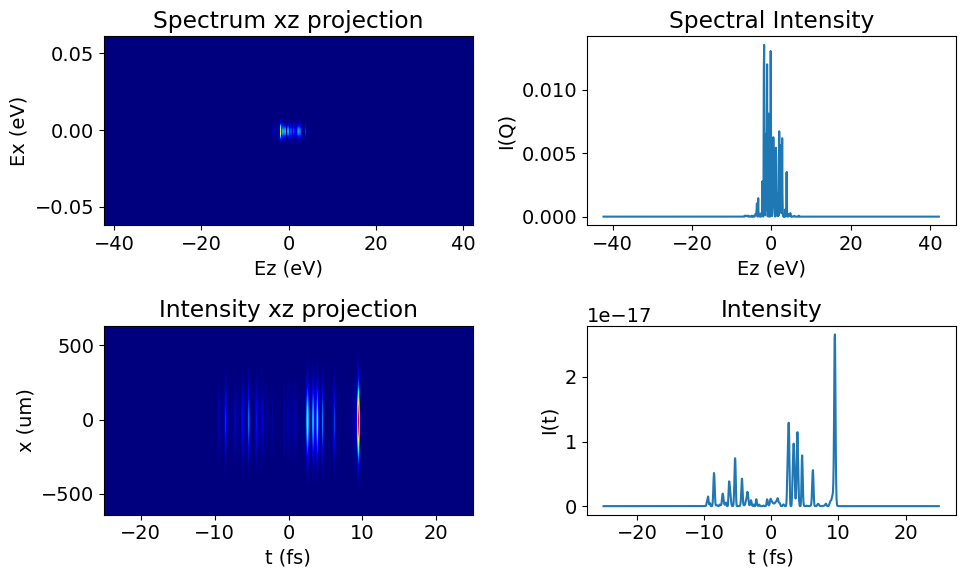

In [8]:
physicalModelVisualization.show_field_spectrum_xz_and_z_slice(summary=simulation_statistics,
                                                              tag_list=["sase spectrum",
                                                                        'sase intensity'],
                                                              coordinate_container=coordinate_dict)

# Step 3: Calculate the electric field after each crystal

In [9]:
print("The locations to investigate the electric field are")
print(expSimu['vcc']['trajectory'])

The locations to investigate the electric field are
[[ 0.00000000e+00  0.00000000e+00 -3.00000000e+06]
 [ 0.00000000e+00  0.00000000e+00 -2.00000000e+06]
 [-2.06415844e+02  2.06415844e+02  2.36738934e+05]
 [-2.10279106e+02  2.69707019e+04  2.68928251e+05]
 [-2.23206586e+02  2.69825201e+04  4.09011479e+05]
 [-2.27068463e+02  2.33258716e+02  4.41193771e+05]
 [-2.47168126e+02  2.49909185e+02  6.58995365e+05]
 [-2.50578771e+02 -2.33738949e+04  6.87417389e+05]
 [-2.65480676e+02 -2.33602714e+04  8.48895653e+05]
 [-2.68800930e+02 -3.57888468e+02  8.76560543e+05]
 [-4.64761014e+02 -1.61932167e+02  3.00000000e+06]
 [-4.64761014e+02 -1.61941072e+02  8.00000000e+06]]


## CC1, perfect align

In [10]:
# Step 1 get the light path after the first CC crystal
observation_point = np.array([0, 0, 6e4])

# Get the trajectory through the targeted optics
device_list = [miniSD_gratings_cc[0], ]
for idx in range(1):
    device_list += cc_channel_cuts[idx].crystal_list

# Get the electric field after the first CC
outputDict, coor_dict = eFieldProcessing.get_efield_with_interpolation(observation_point=observation_point,
                                                                       device_list=device_list,
                                                                       gaussian_pulse=my_pulse,
                                                                       spec_in=sase_spec,
                                                                       kin_grid=kinGrid,
                                                                       coordinate_dict=coordinate_dict,
                                                                       flag_interpolation=False,
                                                                       mode="xyz 3D")
eFieldProcessing.get_statistics(summary_dict=simulation_statistics,
                                array=np.square(np.abs(outputDict['field_grid'])),
                                tag="cc1 perfect intensity")
eFieldProcessing.get_statistics(summary_dict=simulation_statistics,
                                array=np.square(np.abs(outputDict['spectrum_grid'])),
                                tag="cc1 perfect spectrum")

The ray-tracing calculation differ from the actual beam center by a few pixels: [  0  70 238]


/global/common/software/nersc/pe/conda-envs/24.1.0/python-3.11/nersc-python/lib/python3.11/site-packages/numba/cuda/cudadrv/devicearray.py:886: NumbaPerformanceWarning: Host array used in CUDA kernel will incur copy overhead to/from device.
  warn(NumbaPerformanceWarning(msg))


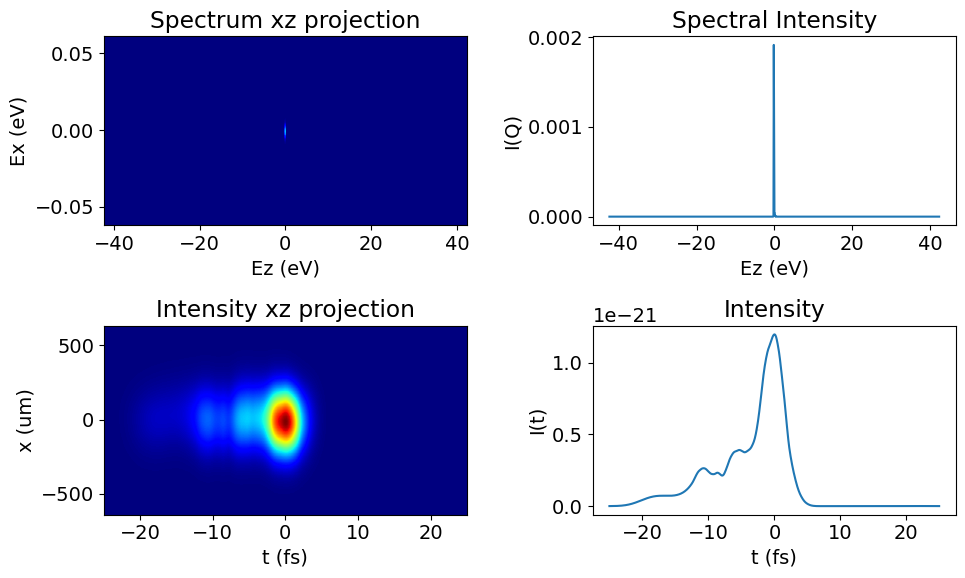

In [11]:
physicalModelVisualization.show_field_spectrum_xz_and_z_slice(summary=simulation_statistics,
                                                              tag_list=["cc1 perfect spectrum",
                                                                        'cc1 perfect intensity'],
                                                              coordinate_container=coordinate_dict)

# CC1 Detune the first crystal

In [12]:
# Step 1 get the light path after the first CC crystal
observation_point = np.array([0, 0, 6e4])

# Get the trajectory through the targeted optics
device_list = [miniSD_gratings_cc[0], ]
for idx in range(1):
    device_list += cc_channel_cuts[idx].crystal_list

# Rotate the second crystal by 4 urad
cc_channel_cuts[0].crystal_list[0].rotate_wrt_point(rot_mat=util.rot_mat_in_yz_plane(theta=2e-6),
                                                    ref_point=np.copy(cc_channel_cuts[0].crystal_list[0].surface_point))
    
# Get the electric field after the first CC
outputDict, coor_dict = eFieldProcessing.get_efield_with_interpolation(observation_point=observation_point,
                                                                       device_list=device_list,
                                                                       gaussian_pulse=my_pulse,
                                                                       spec_in=sase_spec,
                                                                       kin_grid=kinGrid,
                                                                       coordinate_dict=coordinate_dict,
                                                                       flag_interpolation=True,
                                                                       coordinate_info_new={"nx":4,
                                                                                            'ny':128,
                                                                                            'nz':1024,
                                                                                            'dx':4,
                                                                                            'dy':10,
                                                                                            'dz':dz,},
                                                                       mode="xyz 3D")
eFieldProcessing.get_statistics(summary_dict=simulation_statistics,
                                array=np.square(np.abs(outputDict['field_grid'])), #np.square(np.abs(np.roll(outputDict['field_grid'], (0,69 - 69, 177 - 177)))),
                                tag="cc1 detune1 intensity")
eFieldProcessing.get_statistics(summary_dict=simulation_statistics,
                                array=np.square(np.abs(outputDict['spectrum_grid'])) ,
                                tag="cc1 detune1 spectrum")

The ray-tracing calculation differ from the actual beam center by a few pixels: [  0  69 141]
Interpolate the electric field such that after the intpolation
the three axes of the array are parallel to that of the x,y,z axes.
[[ 6.25000000e-02  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  7.81250000e-04 -3.12487547e-09]
 [ 0.00000000e+00  2.66851169e-07  6.67128190e-02]]
[[ 1.60000000e+01  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  1.28000000e+03  5.99561022e-05]
 [ 0.00000000e+00 -5.11999795e-03  1.49896229e+01]]
[3.92699082e-01 8.92619312e-14 0.00000000e+00]
[ 0.00000000e+00  4.90873852e-03 -1.96341716e-08]
[0.00000000e+00 1.67667535e-06 4.19169004e-01]
4 128 1024


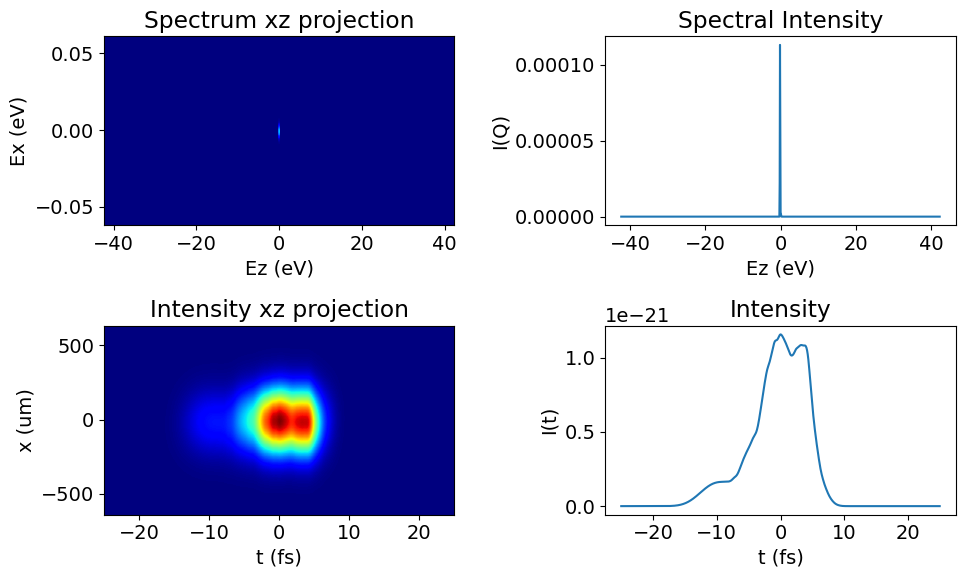

In [13]:
physicalModelVisualization.show_field_spectrum_xz_and_z_slice(summary=simulation_statistics,
                                                              tag_list=["cc1 detune1 spectrum",
                                                                        'cc1 detune1 intensity'],
                                                              coordinate_container=coordinate_dict)

# CC1 Detune the second crystal

In [14]:
# Step 1 get the light path after the first CC crystal
observation_point = np.array([0, 0, 6e4])

# Get the trajectory through the targeted optics
device_list = [miniSD_gratings_cc[0], ]
for idx in range(1):
    device_list += cc_channel_cuts[idx].crystal_list

# Rotate the second crystal by 4 urad
cc_channel_cuts[0].crystal_list[0].rotate_wrt_point(rot_mat=util.rot_mat_in_yz_plane(theta=-2e-6),
                                                    ref_point=np.copy(cc_channel_cuts[0].crystal_list[0].surface_point))

cc_channel_cuts[1].crystal_list[1].rotate_wrt_point(rot_mat=util.rot_mat_in_yz_plane(theta=2e-6),
                                                    ref_point=np.copy(cc_channel_cuts[1].crystal_list[1].surface_point))

# Get the electric field after the first CC
outputDict, coor_dict = eFieldProcessing.get_efield_with_interpolation(observation_point=observation_point,
                                                                       device_list=device_list,
                                                                       gaussian_pulse=my_pulse,
                                                                       spec_in=sase_spec,
                                                                       kin_grid=kinGrid,
                                                                       coordinate_dict=coordinate_dict,
                                                                       flag_interpolation=True,
                                                                       coordinate_info_new={"nx":4,
                                                                                            'ny':128,
                                                                                            'nz':1024,
                                                                                            'dx':4,
                                                                                            'dy':10,
                                                                                            'dz':dz,},
                                                                       mode="xyz 3D")
eFieldProcessing.get_statistics(summary_dict=simulation_statistics,
                                array=np.square(np.abs(outputDict['field_grid'])), #np.square(np.abs(np.roll(outputDict['field_grid'], (0,69 - 69, 177 - 177)))),
                                tag="cc1 detune2 intensity")
eFieldProcessing.get_statistics(summary_dict=simulation_statistics,
                                array=np.square(np.abs(outputDict['spectrum_grid'])),
                                tag="cc1 detune2 spectrum")

The ray-tracing calculation differ from the actual beam center by a few pixels: [  0  70 238]
Interpolate the electric field such that after the intpolation
the three axes of the array are parallel to that of the x,y,z axes.
[[0.0625     0.         0.        ]
 [0.         0.00078125 0.        ]
 [0.         0.         0.06671282]]
[[  16.            0.            0.        ]
 [   0.         1280.00000061    0.        ]
 [   0.            0.           14.9896229 ]]
[3.92699082e-01 2.62012634e-14 0.00000000e+00]
[0.         0.00490874 0.        ]
[0.00000000e+00 7.25197680e-13 4.19169004e-01]
4 128 1024


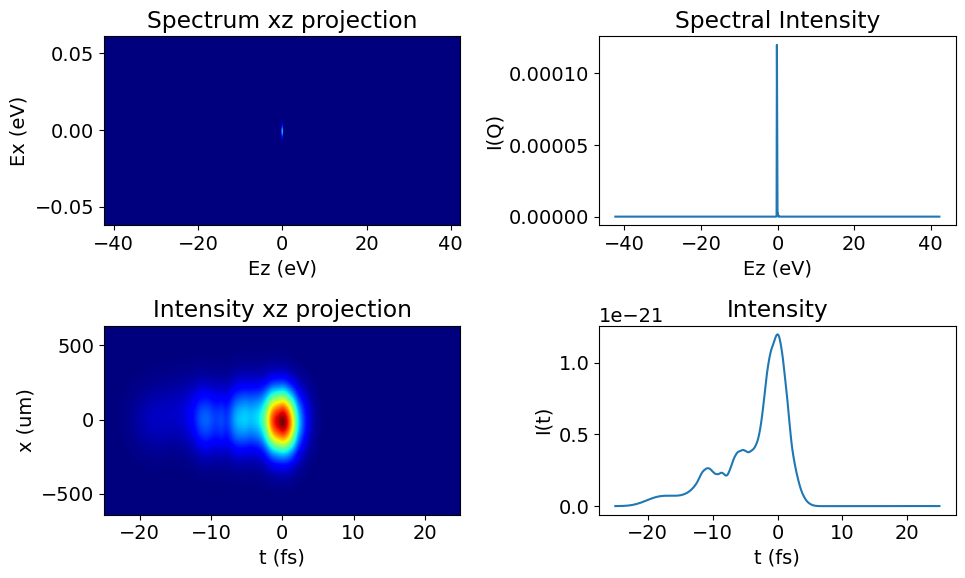

In [15]:
physicalModelVisualization.show_field_spectrum_xz_and_z_slice(summary=simulation_statistics,
                                                              tag_list=["cc1 detune2 spectrum",
                                                                        'cc1 detune2 intensity'],
                                                              coordinate_container=coordinate_dict)

In [16]:
import pickle

with open('../../../../outputData/forYanwen3.pickle', 'wb') as handle:
    pickle.dump(simulation_statistics, handle, protocol=pickle.HIGHEST_PROTOCOL)
    
with open('../../../../outputData/coordinate.pickle', 'wb') as handle:
    pickle.dump(coordinate_dict, handle, protocol=pickle.HIGHEST_PROTOCOL)

In [17]:
simulation_statistics.keys()

dict_keys(['sase intensity', 'sase spectrum', 'cc1 perfect intensity', 'cc1 perfect spectrum', 'cc1 detune1 intensity', 'cc1 detune1 spectrum', 'cc1 detune2 intensity', 'cc1 detune2 spectrum'])

In [20]:
(np.cos(8e-6) - 1 ) * 3e6 / util.c

-0.0003202211134888278